### DIBs VIBS

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports completados")

✓ Imports completados


In [13]:
from pathlib import Path
import sys

cwd = Path().resolve()
for p in [cwd] + list(cwd.parents):
    if (p / "utils").is_dir():
        sys.path.insert(0, str(p))
        break

from utils.download_data_binance import DowloadDataBinance as dt 
from utils.info_bars import InfoBars as ib

In [14]:
data_path = '../data/raw'
info_bars = ib(data_path)
download_data = dt(data_path)

In [15]:
df = download_data.download_trades_binance(
    symbol='BTCUSDT',
    hours=120,  
    max_trades=300000
)

download_data.show_info(df)

Descargando trades de BTCUSDT...
Trades: 200,000 | Iter: 200
✓ Descargados: 200,000 trades
Guardado en: ../data/rawBTCUSDT_trades_20251025_163739.csv

INFORMACIÓN DE LOS DATOS
Total trades: 88,866
Período: 2025-10-20 21:35:57.162000 a 2025-10-21 03:58:36.470000
Duración: 6.4 horas

Primeros 5 trades:
                timestamp      price  quantity  dollar_value
0 2025-10-20 21:35:57.162  110780.00   0.00009      9.970200
1 2025-10-20 21:35:57.258  110779.99   0.00008      8.862399
2 2025-10-20 21:35:59.393  110780.00   0.01264   1400.259200
3 2025-10-20 21:36:00.071  110779.99   0.00021     23.263798
4 2025-10-20 21:36:00.317  110780.00   0.00358    396.592400

Estadísticas:
                           timestamp          price      quantity  \
count                          88866   88866.000000  88866.000000   
mean   2025-10-21 01:01:24.850509312  110091.330010      0.018319   
min       2025-10-20 21:35:57.162000  109131.380000      0.000010   
25%    2025-10-20 23:31:46.873500160  109

In [16]:
tib_bars = info_bars.get_tibs(df)
vib_bars = info_bars.get_vibs(df)
dib_bars = info_bars.get_dibs(df)

In [17]:
print(len(tib_bars), len(vib_bars), len(dib_bars))

25 30 25


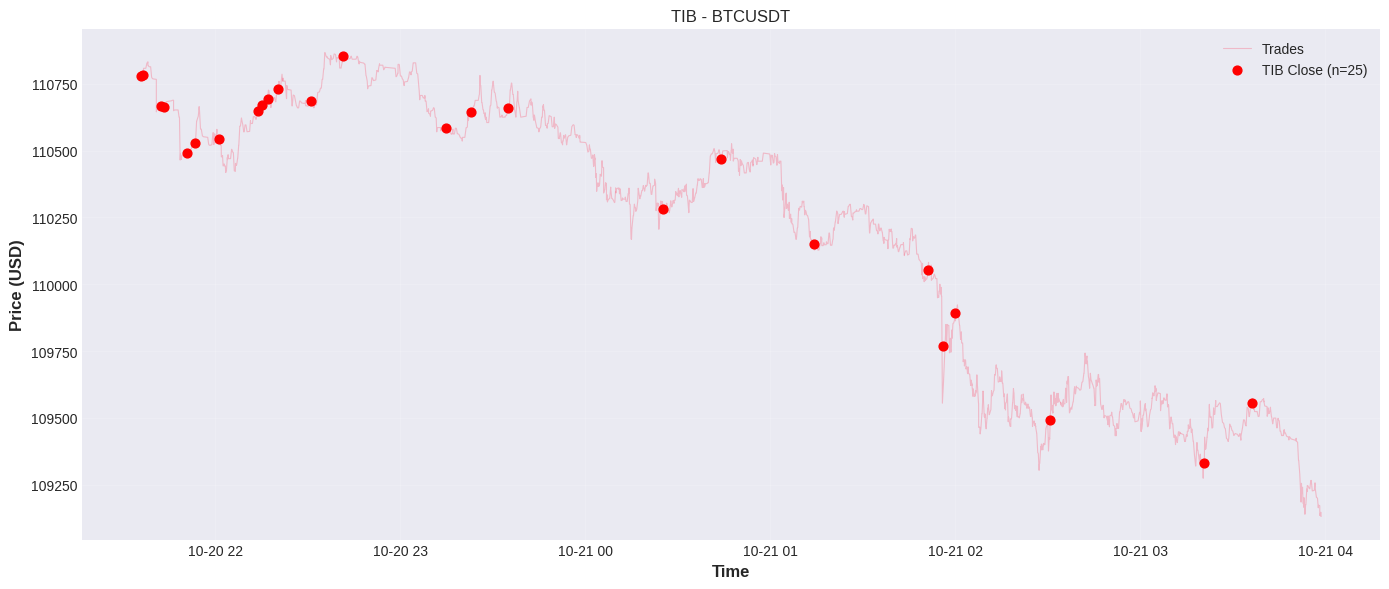

In [18]:
info_bars.plot_bars(df, tib_bars)

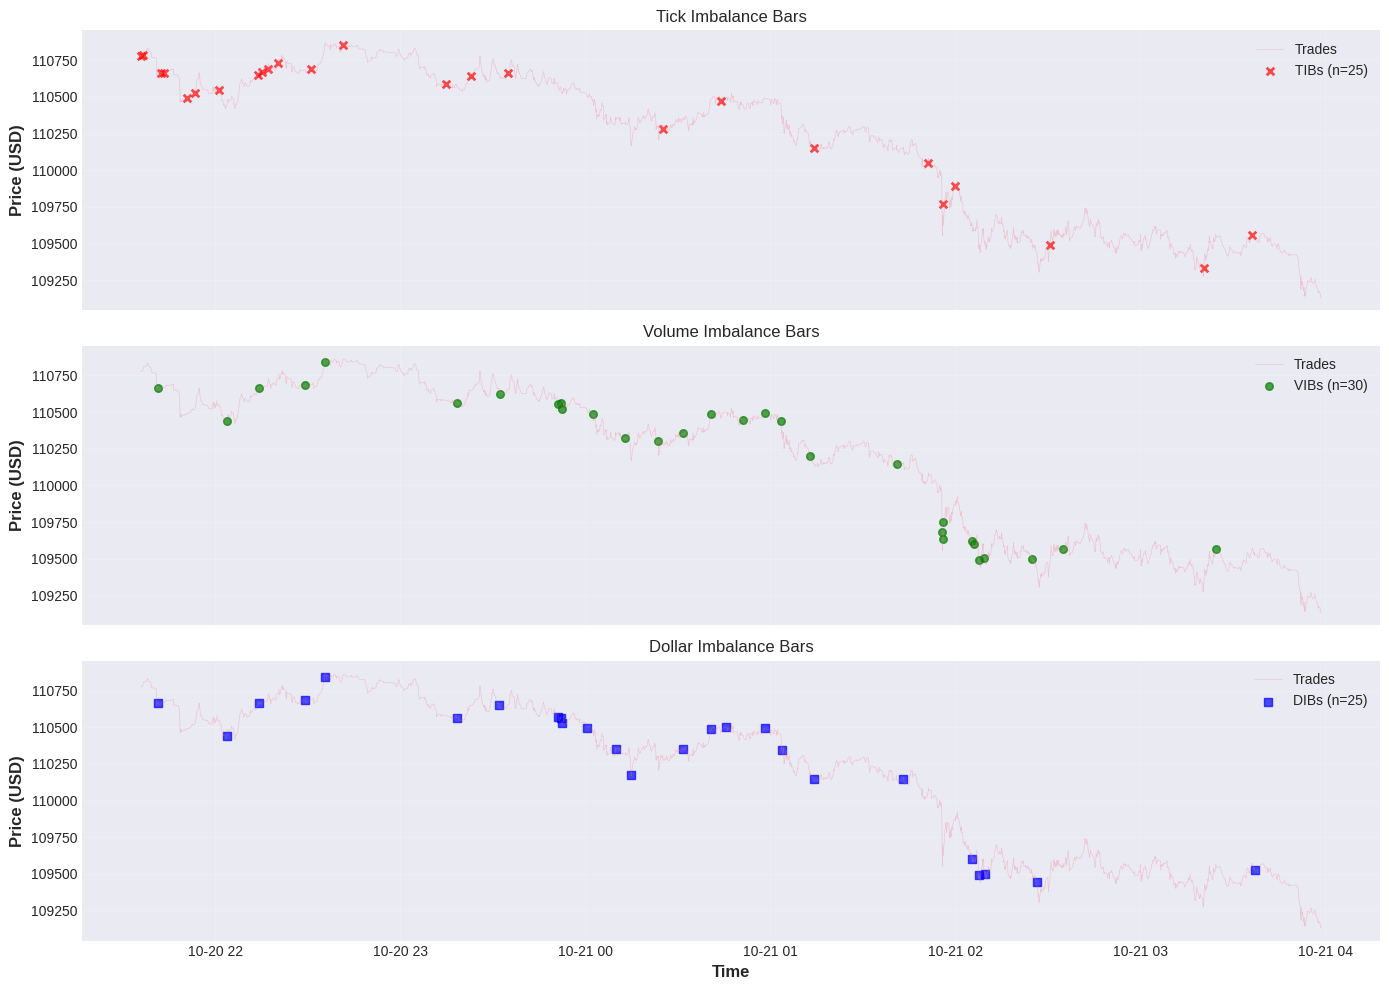

In [19]:
info_bars.plot_comparison(df, tib_bars, vib_bars, dib_bars)

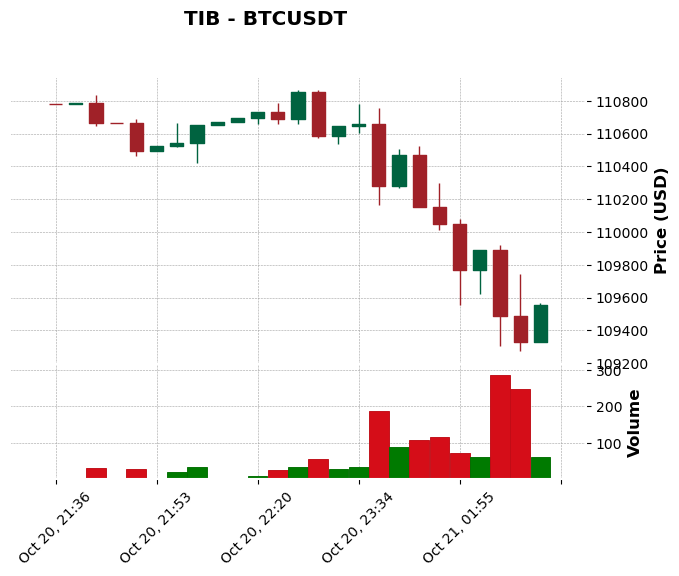

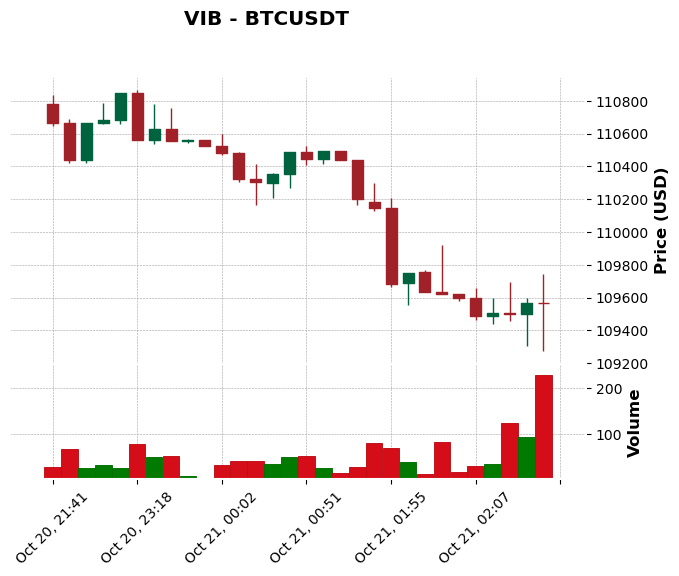

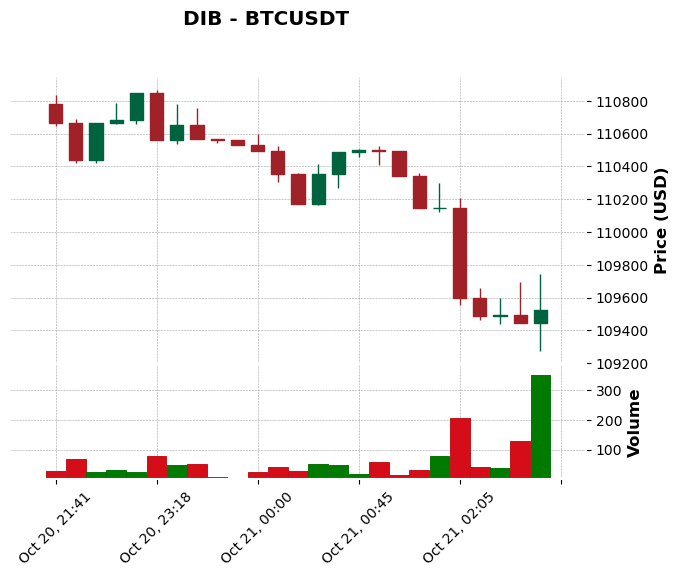

In [21]:
info_bars.candle_bars(tib_bars, bar_type='TIB')
info_bars.candle_bars(vib_bars, bar_type='VIB')
info_bars.candle_bars(dib_bars, bar_type='DIB')